Analyze Data with Python_ניתוח נתוני אפליקציות (Google Play Store)
Project _3 - TALI GEZEHAN DE PICCIOTTO

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# טעינת הנתונים
df = pd.read_csv(r"C:\python\pandas\archive\googleplaystore.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

df = df.drop_duplicates()

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

def clean_size(size):
    if pd.isnull(size):
        return np.nan
    if size == "Varies with device":
        return np.nan
    if "M" in size:
        return float(size.replace("M", ""))
    if "k" in size:
        return float(size.replace("k", "")) / 1024
    return np.nan

df["Size"] = df["Size"].apply(clean_size)

# המרת תאריך
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

# טיפול בערכים חסרים
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

# יצירת עמודות זמן
df["Update_Year"] = df["Last Updated"].dt.year
df["Update_Month"] = df["Last Updated"].dt.month

# סטטיסטיקה תיאורית
print(df[["Rating", "Reviews", "Installs", "Price", "Size"]].describe())

# קיבוץ לפי קטגוריה
print(df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(10))



                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

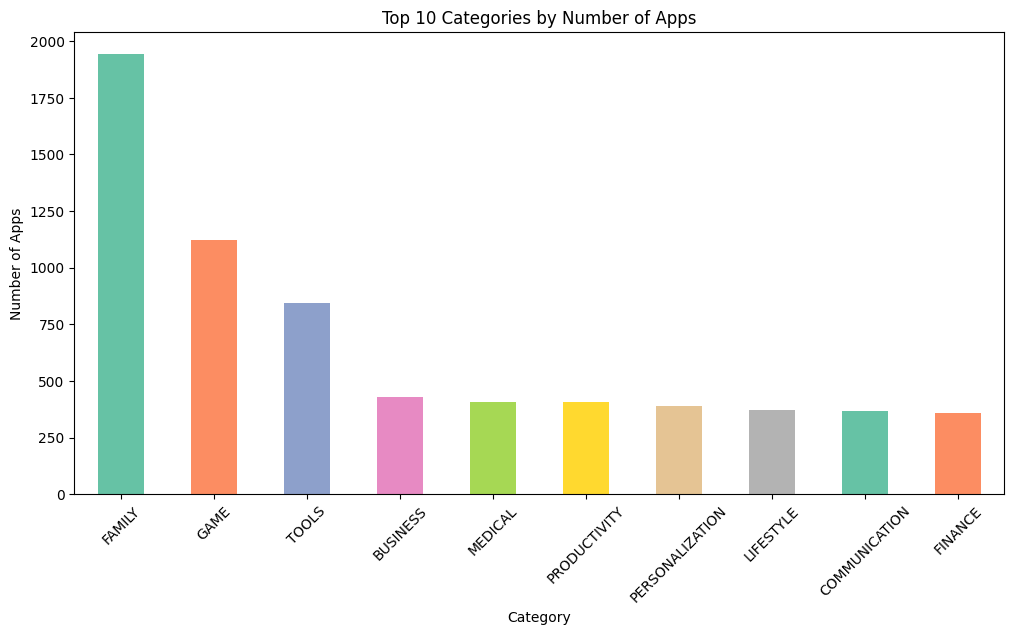

In [9]:
# גרף עמודות
plt.figure(figsize=(12, 6))
colors = sns.color_palette("Set2", 10)
df["Category"].value_counts().head(10).plot(kind="bar", color=colors)
plt.title("Top 10 Categories by Number of Apps")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()


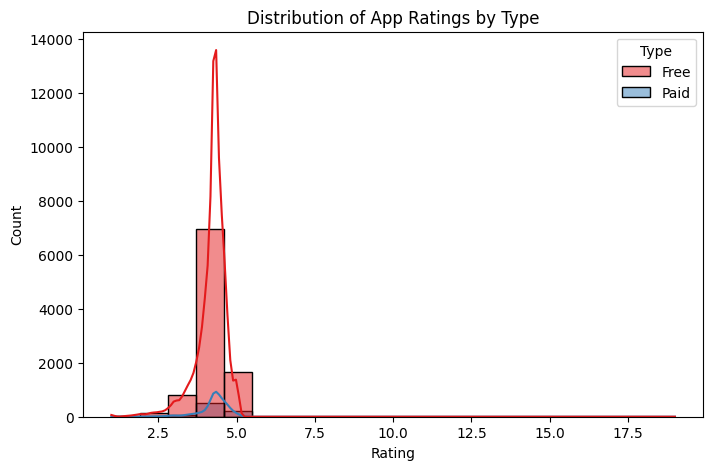

In [34]:
# היסטוגרמה
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rating", bins=20, kde=True, hue="Type",
             hue_order=["Free", "Paid"], palette="Set1")
plt.title("Distribution of App Ratings by Type")
plt.show()

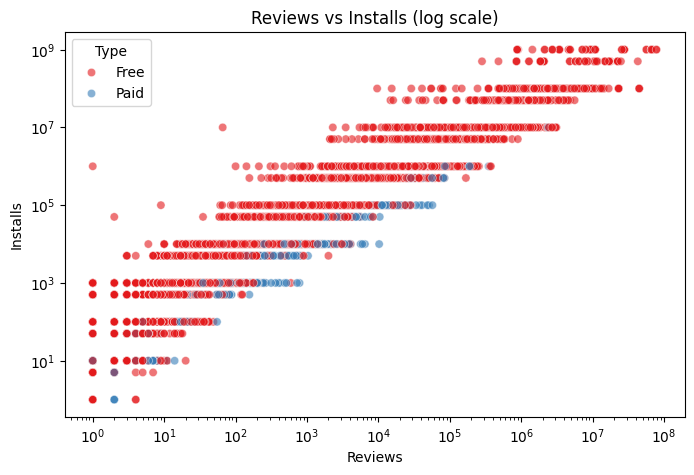

In [38]:
# גרף פיזור
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Reviews", y="Installs", hue="Type",
                hue_order=["Free", "Paid"], palette="Set1", alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.title("Reviews vs Installs (log scale)")
plt.show()

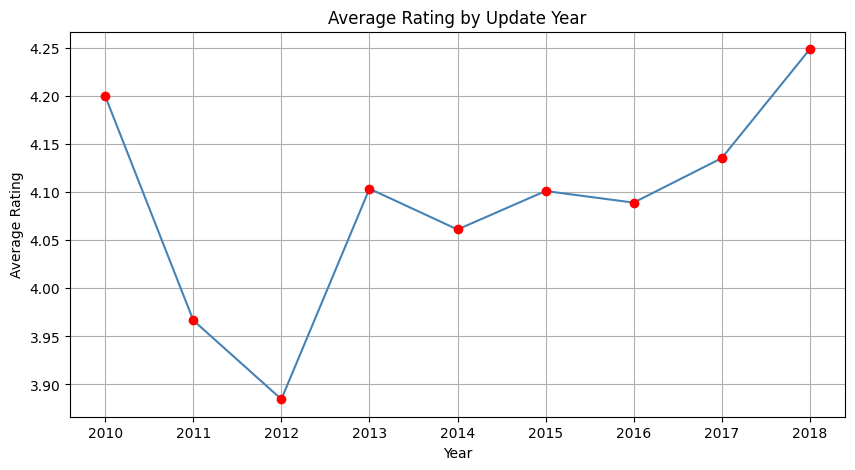

In [27]:
# גרף קו לפי שנה
rating_per_year = df.groupby("Update_Year")["Rating"].mean()
plt.figure(figsize=(10, 5))
plt.plot(rating_per_year.index, rating_per_year.values,
         color="steelblue", marker="o",
         markerfacecolor="red", markeredgecolor="red", markersize=6)
plt.title("Average Rating by Update Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

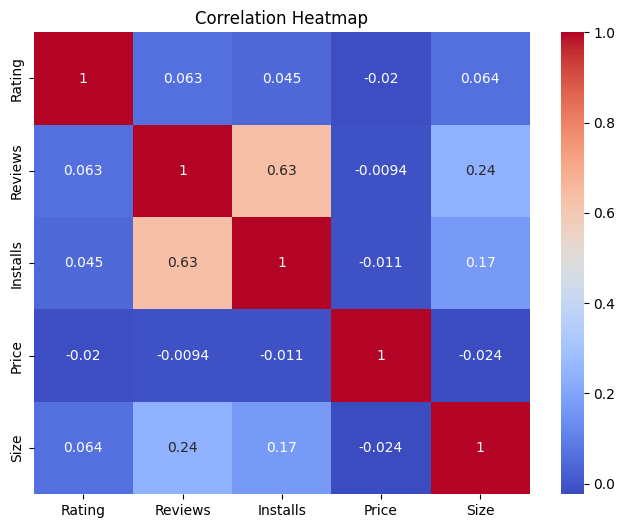

In [13]:
# מפת חום
plt.figure(figsize=(8, 6))
corr = df[["Rating", "Reviews", "Installs", "Price", "Size"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

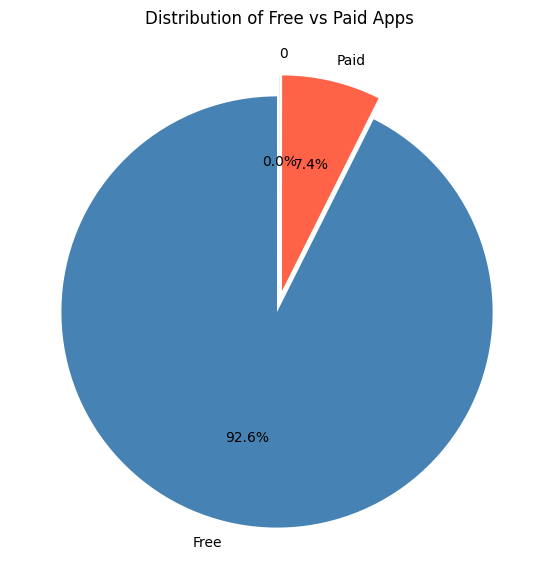

In [ ]:
# צ'ארט פאי 
import matplotlib.pyplot as plt
app_type_counts = df["Type"].value_counts()
explode = [0.05] * len(app_type_counts)
colors = ["steelblue", "red"]
plt.figure(figsize=(7,7))
plt.pie(app_type_counts, labels=app_type_counts.index, autopct='%1.1f%%', startangle=90,
        explode=explode, shadow=False, colors=colors)
plt.title("Distribution of Free vs Paid Apps")
plt.show()

In [4]:
#3.8 Summary and Conclusions
#Most apps in the Google Play Store dataset are free, 
#and free apps generally have more installs than paid apps. 
#The analysis also shows that apps with more reviews usually have more installs, 
#which suggests that reviews are a strong indicator of popularity. 
#In addition, some categories are much more competitive than others because they contain a larger number of apps.
#The results do not show a strong relationship between price and rating, 
# but they do reveal clear differences between categories in terms of ratings, 
#reviews, and installs. Based on these findings, developers should consider using a free app model, 
#improving user experience to encourage reviews, 
#and studying category competition before launching a new app. 
#Future research could include sentiment analysis of user 
# reviews or predicting app success based on app features.

גם רציתי להגיד לך תודה אישית אלעד, למדתי ממך המון, ואני מודה לך ממש על כל רגע. 
 השיעורים שלך היו מעשירים ומעניינים , אני מקווה שאני כבר אתחיל להפיק מהם תוצרים מעולים 
 תודה רבה